In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
METHOD_ORDER = ["FBAproBasic", "FBAproPartial", "FBAproFixed", "FBAproFull",
                "FBA", "MoMA", "iMAT"]
def set_method_order(df, col='method'):
    present = [m for m in METHOD_ORDER if m in df[col].unique()]
    df[col] = pd.Categorical(df[col], categories=present, ordered=True)
    return df

In [3]:
synthetic_cobra_data = pd.read_csv("synthetic_data_experiment_files/outputs/RECON1_cobra_base_n1.00_k0.020_u0.850_eps1e-5_rs10_ns25/correlation_results.csv")
synthetic_basis_data = pd.read_csv("synthetic_data_experiment_files/outputs/RECON1_basis_base_n1.00_k0.020_u0.850_eps1e-5_rs10_ns25/correlation_results.csv")

real_loo_data = pd.read_csv("real_data_experiment_files/figures/loo_data_non_joint.csv")
real_full_data = pd.read_csv("real_data_experiment_files/figures/fluxmapped_full_predictions.csv")


timing_data = pd.read_csv("synthetic_data_experiment_files/outputs/figure_recreation_data/runtimes_df")
varying_samples_runtimes_df = pd.read_csv("synthetic_data_experiment_files/outputs/figure_recreation_data/amortized_runtimes_df")

In [4]:
timing_data.loc[(timing_data['device']=='CPU') & (timing_data['method']=='FBAproBasic')]

,Unnamed: 0,organism,reactions,method,batch,device,time,organism_device_batch,device_batch
2,2,e_coli_core,95,FBAproBasic,1,CPU,0.000777,"e_coli_core, CPU, 1","CPU, 1"
3,3,e_coli_core,95,FBAproBasic,1,CPU,0.000156,"e_coli_core, CPU, 1","CPU, 1"
4,4,e_coli_core,95,FBAproBasic,1,CPU,0.000135,"e_coli_core, CPU, 1","CPU, 1"
5,5,e_coli_core,95,FBAproBasic,1,CPU,0.000131,"e_coli_core, CPU, 1","CPU, 1"
6,6,e_coli_core,95,FBAproBasic,1,CPU,0.000122,"e_coli_core, CPU, 1","CPU, 1"
...,...,...,...,...,...,...,...,...,...
2312,2312,e_coli_K_12,2712,FBAproBasic,1,CPU,0.006136,"e_coli_K_12, CPU, 1","CPU, 1"
2313,2313,e_coli_K_12,2712,FBAproBasic,1,CPU,0.006144,"e_coli_K_12, CPU, 1","CPU, 1"
2314,2314,e_coli_K_12,2712,FBAproBasic,1,CPU,0.006071,"e_coli_K_12, CPU, 1","CPU, 1"
2315,2315,e_coli_K_12,2712,FBAproBasic,1,CPU,0.006151,"e_coli_K_12, CPU, 1","CPU, 1"


In [5]:
# Separate benchmarks from FBApro variants
timing_data.loc[~timing_data['method'].str.contains("FBApro"), 'device_batch'] = 'Benchmarks\nCPU\n1 sample'
timing_data.loc[timing_data['method'].str.contains("FBApro"), 'device_batch'] = 'FBApro\n' + timing_data.loc[timing_data['method'].str.contains("FBApro"), 'device_batch'].str.replace('1', '1 sample').str.replace('50', '50 samples').str.replace(", ", "\n")


In [6]:
# Remove Fixed and Full from real data (nothing should be considered as fully measured)
# real_loo_data = real_loo_data.loc[~real_loo_data['method'].str.contains("FBAproF")]
# real_full_data = real_full_data.loc[~real_full_data['method'].str.contains("FBAproF")]

In [7]:
# only consider NCI60 exchanges data
real_loo_data = real_loo_data.rename(columns={"data": "input data"})
real_loo_data = real_loo_data.loc[real_loo_data['input data'] == "NCI60 exchanges"]
real_full_data = real_full_data.loc[real_full_data['target data'] == "NCI60 exchanges"]

In [8]:
# only take the noisy masking from synthetic data
synthetic_cobra_data = synthetic_cobra_data.loc[synthetic_cobra_data['masking'] == 'noisy']
synthetic_basis_data = synthetic_basis_data.loc[synthetic_basis_data['masking'] == 'noisy']

In [9]:
synthetic_combined = pd.concat([synthetic_cobra_data, synthetic_basis_data], 
                               keys=['cobrapy sampling', 'linear basis sampling'])
real_combined = pd.concat([real_loo_data, real_full_data], 
                          keys=['leave-one-out Exchange Rates', 'GE integration'])

In [10]:
# replace NANs with zeros
synthetic_combined = synthetic_combined.rename(columns={'value': 'Spearman correlation'})
synthetic_combined['Spearman correlation'] = synthetic_combined['Spearman correlation'].fillna(0)

real_combined = real_combined.rename(columns={'correlation': 'Spearman correlation'})
real_combined['Spearman correlation'] = real_combined['Spearman correlation'].fillna(0)

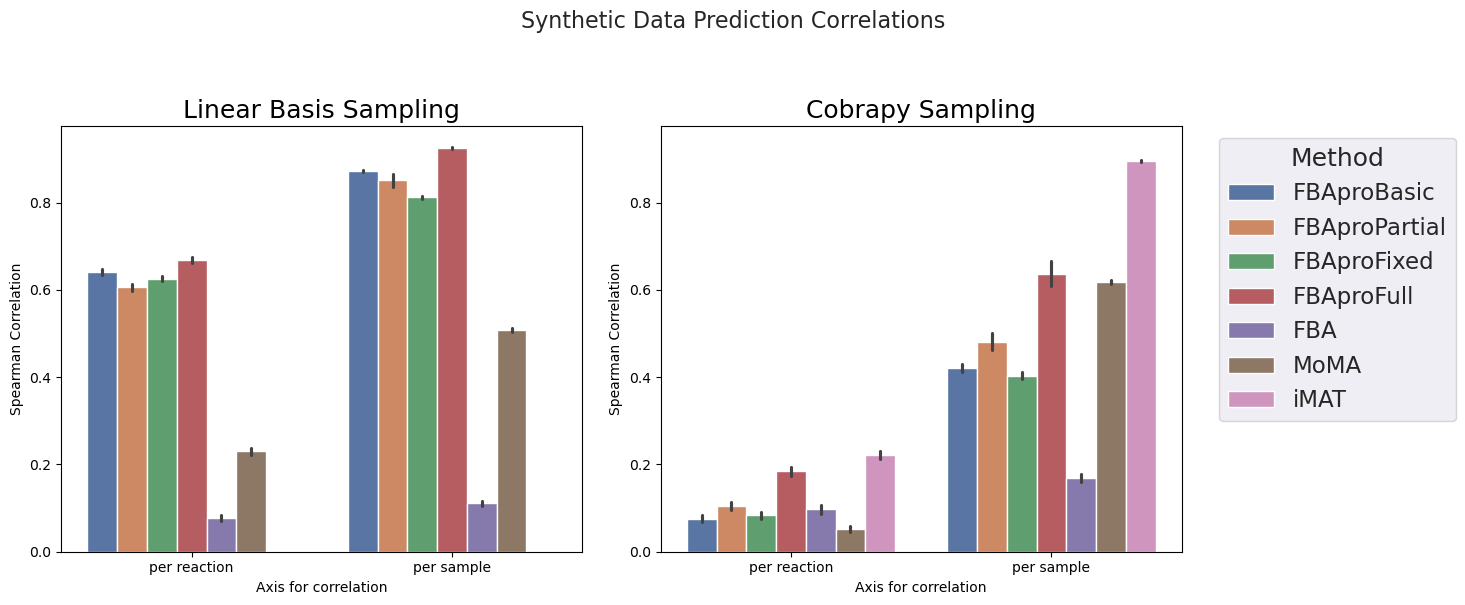

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
sns.set(style="darkgrid", font_scale=1.5)
sns.barplot(
    data=set_method_order(
        synthetic_combined.loc[synthetic_combined.index.get_level_values(0)=='linear basis sampling'].sort_values(by=['axis', 'method'])),
    x="axis", y="Spearman correlation", hue="method", ax=axes[0], hue_order=METHOD_ORDER)
axes[0].set_title("Linear Basis Sampling")
axes[0].set_xlabel("Axis for correlation")
axes[0].set_ylabel("Spearman Correlation")
# remove legend from first plot
axes[0].legend_.remove()
sns.barplot(
    data=set_method_order(
        synthetic_combined.loc[synthetic_combined.index.get_level_values(0)=='cobrapy sampling'].sort_values(by=['axis', 'method'])),
    x="axis", y="Spearman correlation", hue="method", ax=axes[1], hue_order=METHOD_ORDER)
axes[1].set_title("Cobrapy Sampling")
axes[1].set_xlabel("Axis for correlation")
axes[1].set_ylabel("Spearman Correlation")

axes[1].tick_params(left=True, labelleft=True)
axes[1].yaxis.get_label().set_visible(True)
axes[1].legend(title="Method", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.suptitle("Synthetic Data Prediction Correlations", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3073072/3605717569.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = pd.Categorical(df[col], categories=present, ordered=True)
/tmp/ipykernel_3073072/3605717569.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = pd.Categorical(df[col], categories=present, ordered=True)


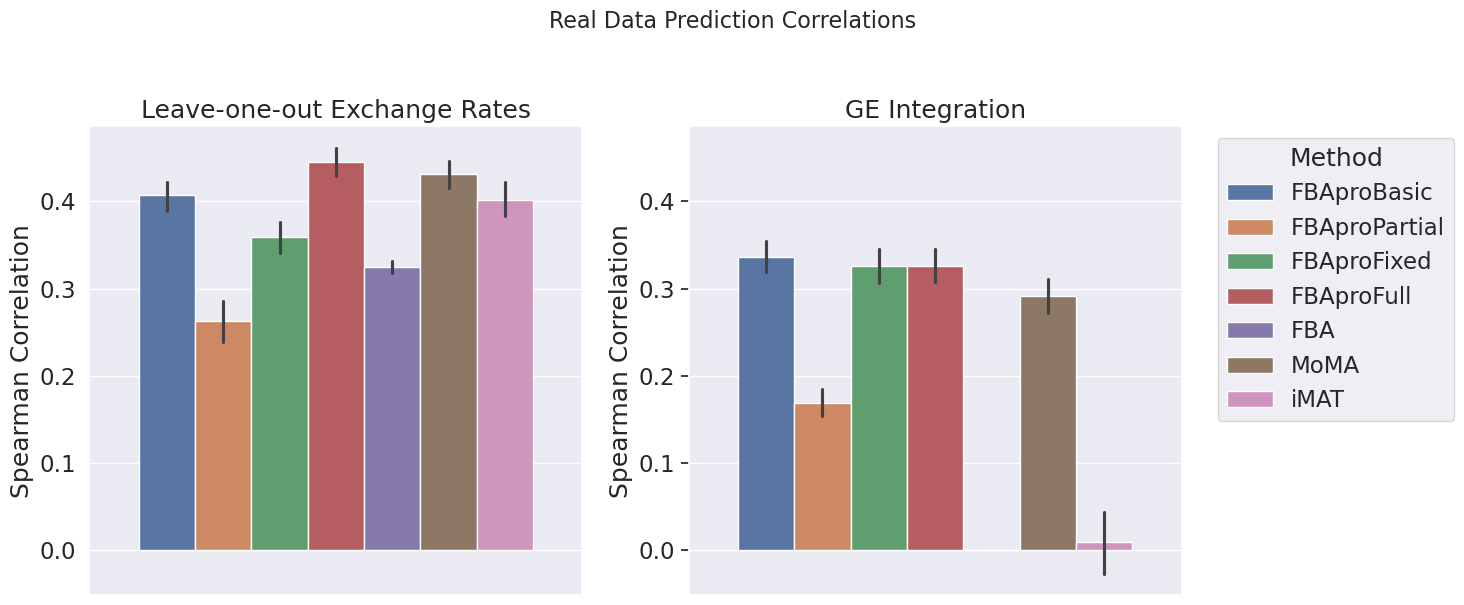

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
data = real_combined.loc[real_combined['axis'] == 'sample']
sns.set(style="darkgrid", font_scale=1.5)
sns.barplot(
    data=set_method_order(data).loc[~(data.index.get_level_values(0) == 'GE integration')],
    y="Spearman correlation", hue="method", ax=axes[0], hue_order=METHOD_ORDER)
axes[0].set_title("Leave-one-out Exchange Rates")
axes[0].set_ylabel("Spearman Correlation")
# remove legend from first plot
axes[0].legend_.remove()
sns.barplot(
    data=set_method_order(data).loc[data.index.get_level_values(0) == 'GE integration'],
    y="Spearman correlation", hue="method", ax=axes[1], hue_order=METHOD_ORDER)
axes[1].set_title("GE Integration")
axes[1].set_ylabel("Spearman Correlation")
axes[1].tick_params(left=True, labelleft=True)
axes[1].yaxis.get_label().set_visible(True)
axes[1].legend(title="Method", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.suptitle("Real Data Prediction Correlations", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [13]:
real_combined.loc[(real_combined['axis']=='sample') & (real_combined['method']=='FBAproBasic') & (real_combined['target data']=='NCI60 exchanges')].shape

(45, 8)

/tmp/ipykernel_3073072/2941393942.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['method'] = data['method'].str.replace("_setup", "")


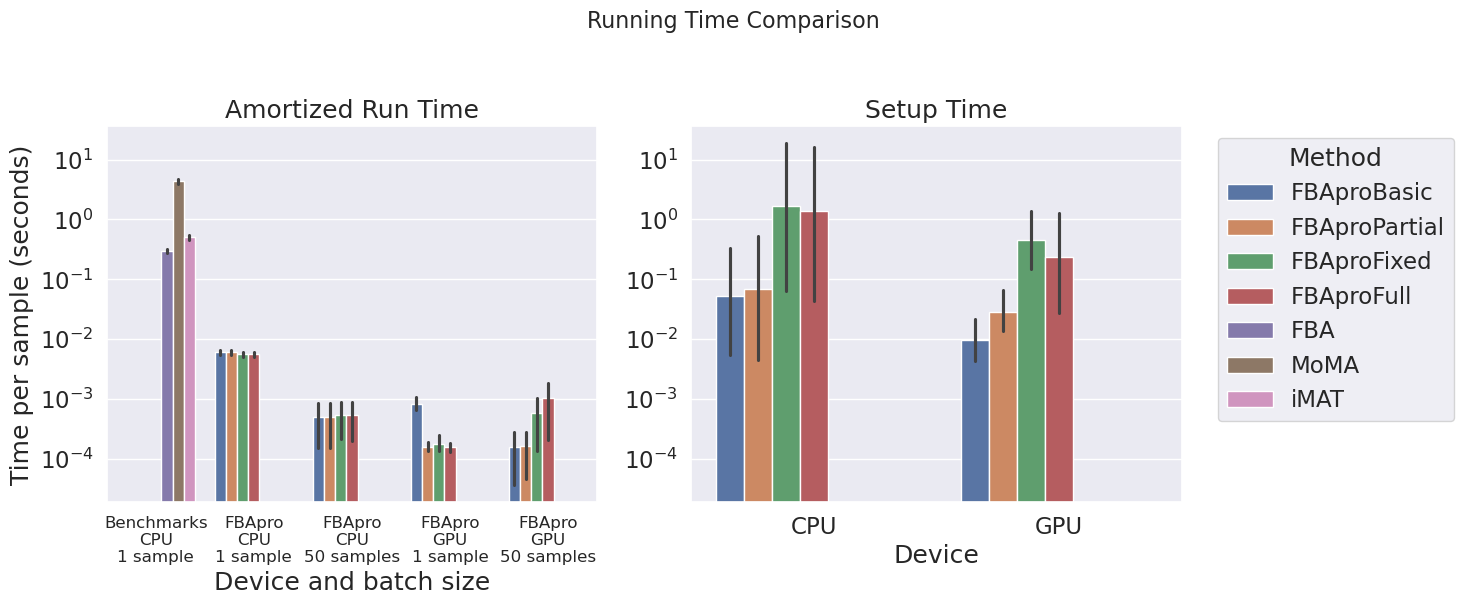

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
sns.set(style="darkgrid", font_scale=1.5)
sns.barplot(
    data=set_method_order(
        timing_data.loc[~timing_data['method'].str.contains("setup")].sort_values(by=['method', 'device_batch'])),
    x="device_batch", y="time", hue="method", ax=axes[0], hue_order=METHOD_ORDER)
axes[0].set_title("Amortized Run Time")
axes[0].set_xlabel("Device and batch size")
axes[0].tick_params(axis='x', labelsize=12)
axes[0].set_ylabel("Time per sample (seconds)")
axes[0].set_yscale('log')
# remove legend from first plot
axes[0].legend_.remove()
data = timing_data.loc[timing_data['method'].str.contains("setup")]
data['method'] = data['method'].str.replace("_setup", "")
sns.barplot(
    data=set_method_order(
        data.sort_values(by=['method', 'device_batch'])),
    x="device", y="time", hue="method", ax=axes[1], hue_order=METHOD_ORDER)
axes[1].set_title("Setup Time")
axes[1].set_xlabel("Device")
axes[1].set_ylabel("Time (seconds)")
axes[1].legend(title="Method", bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].set_yscale('log')
axes[1].tick_params(labelleft=True)
plt.suptitle("Running Time Comparison", fontsize=16, y=1.02)
plt.tight_layout()

plt.show()

In [15]:
is_cpu_setup = (timing_data['method'].str.contains("setup") & ~timing_data['device_batch'].str.contains("GPU"))
is_benchmark = ~timing_data['method'].str.contains("FBApro")
is_gpu_50 = timing_data['method'].str.contains("FBApro") & timing_data['device_batch'].str.contains('GPU') & timing_data['device_batch'].str.contains('50')
benchmarks_gpubatch_setup = timing_data.copy()
benchmarks_gpubatch_setup.loc[is_cpu_setup, 'type'] = 'FBApro Setup\nCPU'
benchmarks_gpubatch_setup.loc[is_benchmark, 'type'] = 'Benchmarks\nCPU, 1 sample'
benchmarks_gpubatch_setup.loc[is_gpu_50, 'type'] = 'FBApro\nGPU, 50 samples'
benchmarks_gpubatch_setup.loc[is_cpu_setup, 'method'] = benchmarks_gpubatch_setup.loc[is_cpu_setup, 'method'].str.replace("_setup", "")
# print(benchmarks_gpubatch_setup.loc[is_cpu_setup])
benchmarks_gpubatch_setup = benchmarks_gpubatch_setup.loc[is_cpu_setup | is_benchmark | is_gpu_50]

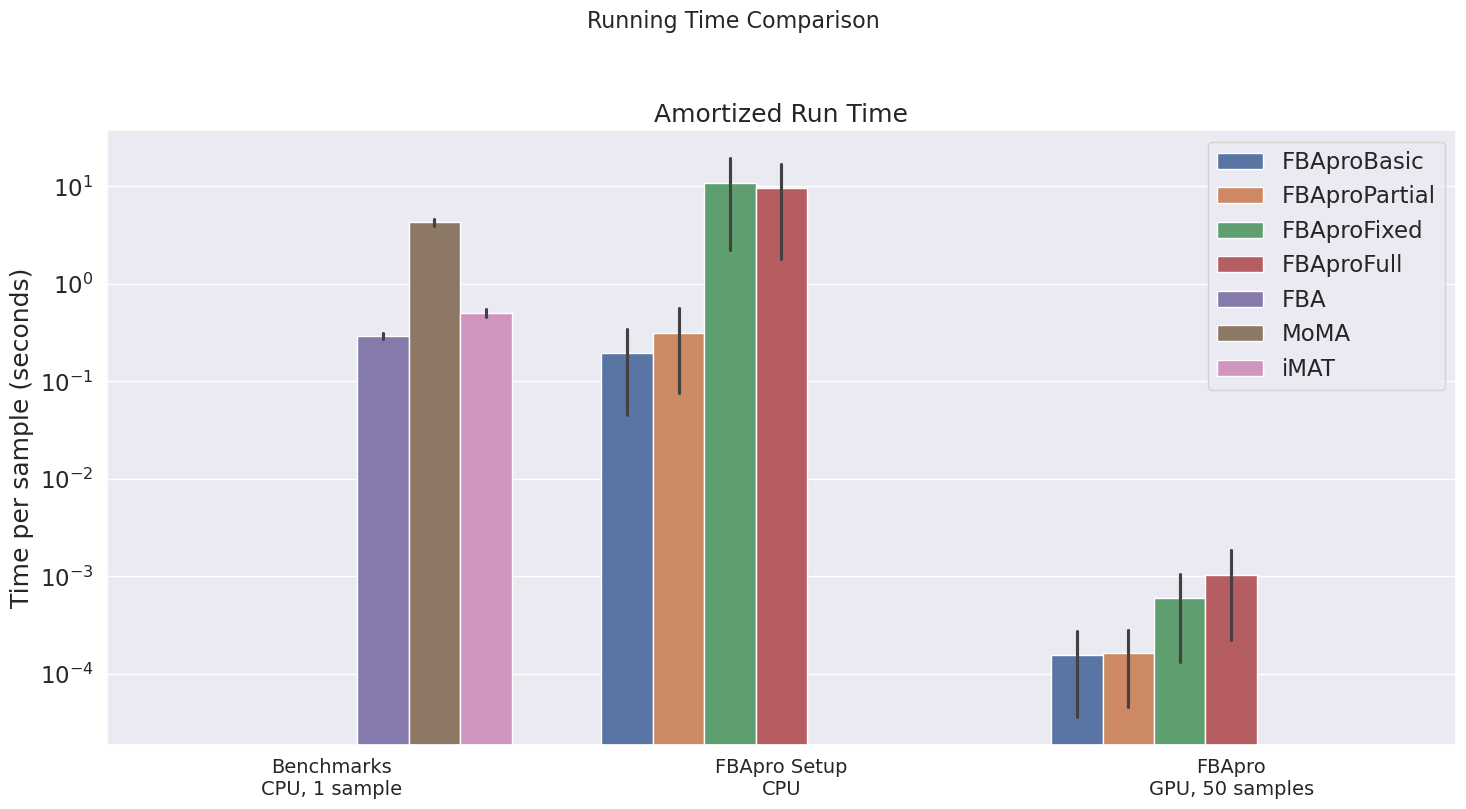

In [16]:
fig = plt.figure(figsize=(15, 8))
sns.set(style="darkgrid", font_scale=1.5)
ax = sns.barplot(
    data=set_method_order(benchmarks_gpubatch_setup.sort_values(by=['method', 'device_batch'])),
    x="type", y="time", hue="method", hue_order=METHOD_ORDER)
ax.set_title("Amortized Run Time")
ax.set_xlabel("")
ax.tick_params(axis='x', labelsize=14)
ax.set_ylabel("Time per sample (seconds)")
ax.set_yscale('log')
ax.legend(loc='upper right')

plt.suptitle("Running Time Comparison", fontsize=16, y=1.02)
plt.tight_layout()

plt.show()

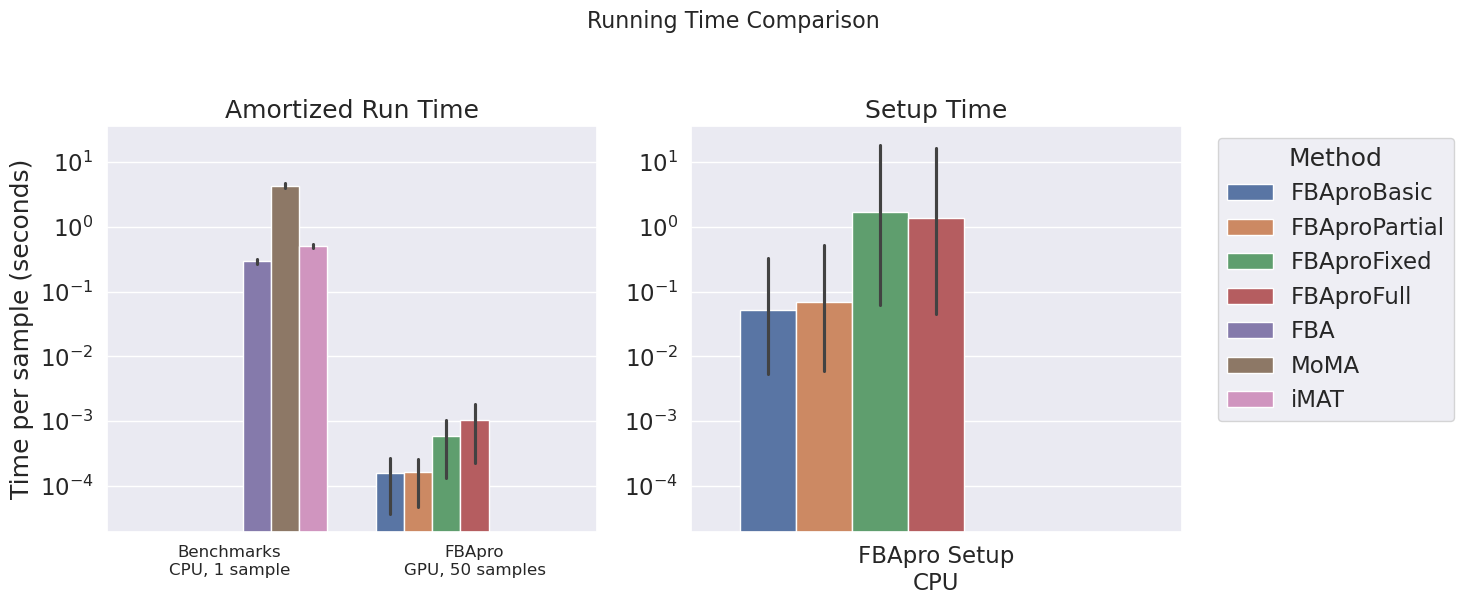

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
sns.set(style="darkgrid", font_scale=1.5)
sns.barplot(
    data=set_method_order(
        benchmarks_gpubatch_setup.loc[~benchmarks_gpubatch_setup['type'].str.contains("Setup")].sort_values(by=['method', 'device_batch'])),
    x="type", y="time", hue="method", ax=axes[0], hue_order=METHOD_ORDER)
axes[0].set_title("Amortized Run Time")
axes[0].set_xlabel("")
axes[0].tick_params(axis='x', labelsize=12)
axes[0].set_ylabel("Time per sample (seconds)")
axes[0].set_yscale('log')
# remove legend from first plot
axes[0].legend_.remove()
data = benchmarks_gpubatch_setup.loc[benchmarks_gpubatch_setup['type'].str.contains("Setup")]
sns.barplot(
    data=set_method_order(
        data.sort_values(by=['method', 'device_batch'])),
    x="type", y="time", hue="method", ax=axes[1], hue_order=METHOD_ORDER)
axes[1].set_title("Setup Time")
axes[1].set_xlabel("")
axes[1].set_ylabel("Time (seconds)")
axes[1].legend(title="Method", bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].set_yscale('log')
axes[1].tick_params(labelleft=True)
plt.suptitle("Running Time Comparison", fontsize=16, y=1.02)
plt.tight_layout()

plt.show()

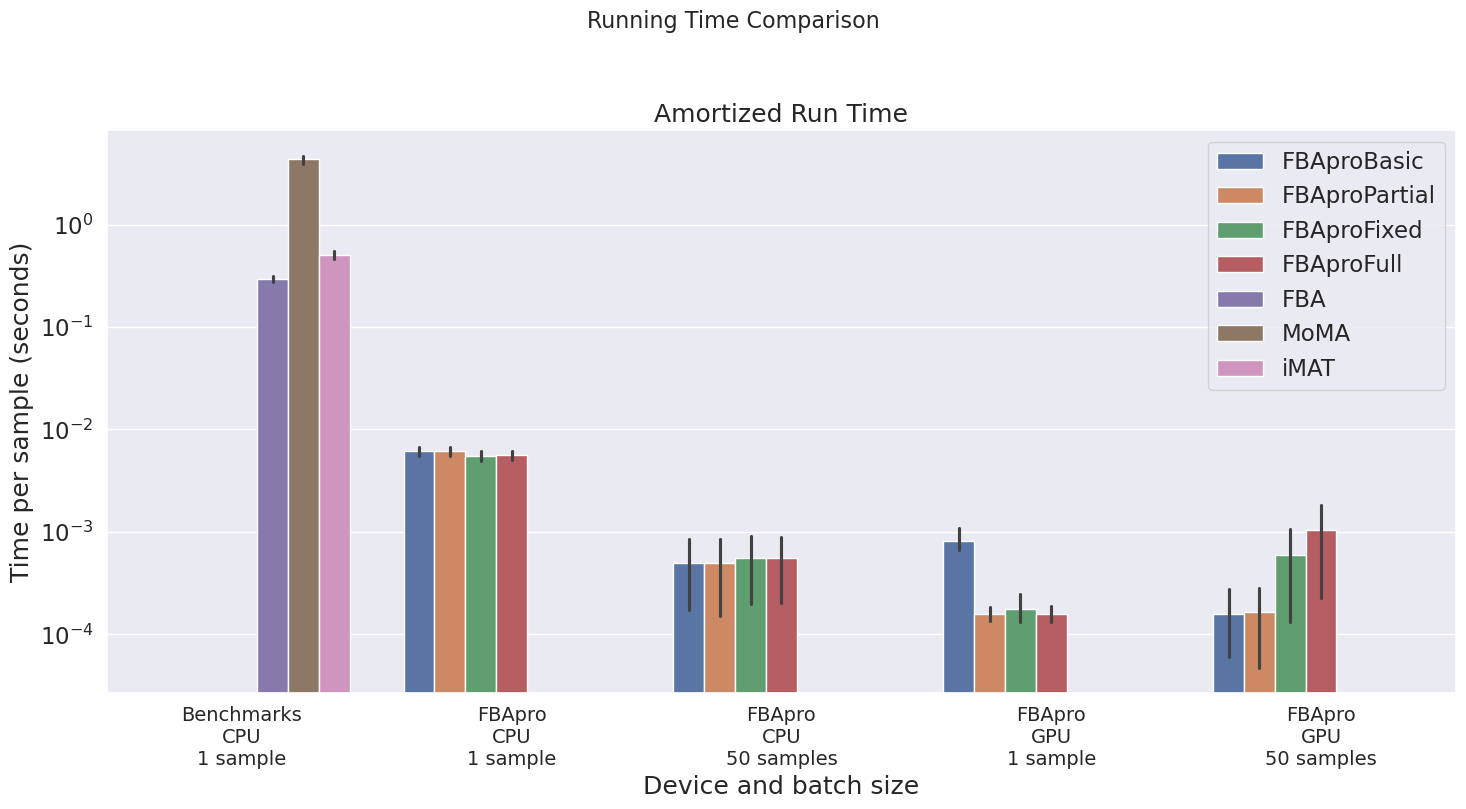

In [18]:
fig = plt.figure(figsize=(15, 8))
sns.set(style="darkgrid", font_scale=1.5)
ax = sns.barplot(
    data=set_method_order(
        timing_data.loc[~timing_data['method'].str.contains("setup")].sort_values(by=['method', 'device_batch'])),
    x="device_batch", y="time", hue="method", hue_order=METHOD_ORDER)
ax.set_title("Amortized Run Time")
ax.set_xlabel("Device and batch size")
ax.tick_params(axis='x', labelsize=14)
ax.set_ylabel("Time per sample (seconds)")
ax.set_yscale('log')
ax.legend(loc='upper right')

plt.suptitle("Running Time Comparison", fontsize=16, y=1.02)
plt.tight_layout()

plt.show()

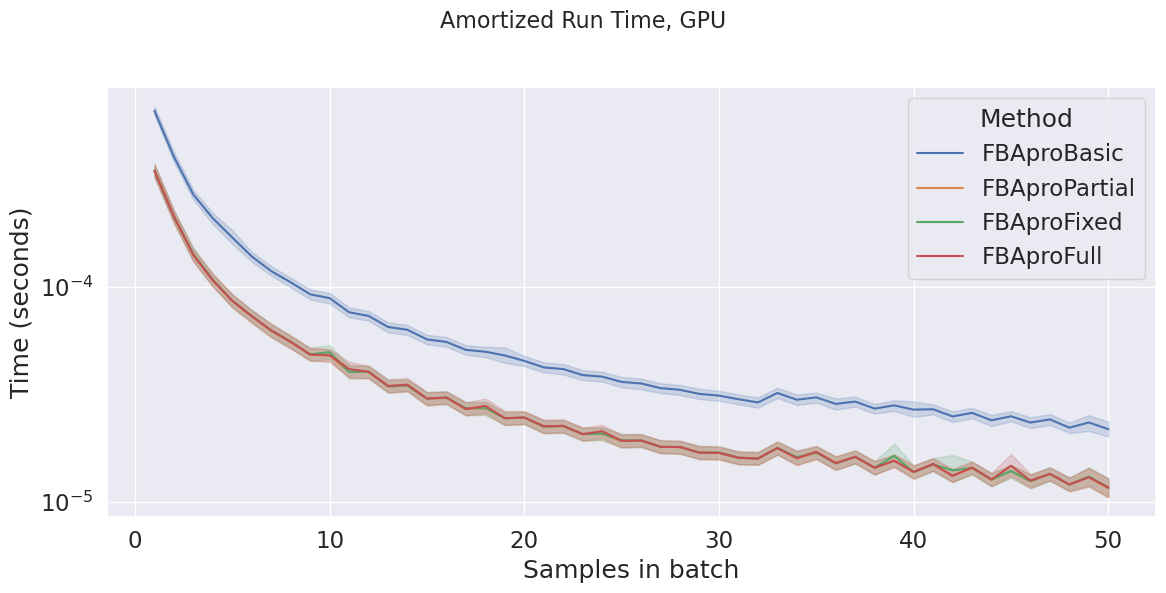

In [19]:
plt.figure(figsize=(12, 6))
sns.set(style="darkgrid", font_scale=1.5)
data = set_method_order(varying_samples_runtimes_df).rename(columns=({'method': 'Method', 'time': 'Time'}))
g = sns.lineplot(
    data=data,
    x='batch', y="Time", hue="Method")
g.set(xlabel="Samples in batch", ylabel="Time (seconds)")
plt.suptitle("Amortized Run Time, GPU", fontsize=16, y=1.00)
g.set_yscale('log')
plt.tight_layout()
plt.show()

In [20]:
real_loo_data.loc[real_loo_data['method']=='FBAproBasic'].loc[real_loo_data['axis']=='sample'].shape

(52, 6)